In [ ]:
!unzip "/content/drive/MyDrive/tiny-imagenet-200.zip" -d /content/dataset


Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_3979.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_3963.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_7199.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_2752.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_9687.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_9407.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_3603.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_3412.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_6982.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_8496.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_7332.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/val/images/val_9241.JPEG  
  inflating: /content/dataset/tiny-imagenet-200/v

In [ ]:
## to ignore all the warning
import warnings
warnings.filterwarnings('ignore')

In [ ]:
### Imports ###
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler, TensorBoard
from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image
import tensorflow.keras.backend as K

import matplotlib.pyplot as plt

import numpy as np
import os
import random
import scipy.misc
from tqdm import *

/tmp/ipykernel_5505/1349283749.py:13: DeprecationWarning: scipy.misc is deprecated and will be removed in 2.0.0
  import scipy.misc


In [ ]:
DATA_DIR = "/content/dataset/tiny-imagenet-200"
TRAIN_DIR = os.path.join(DATA_DIR, "train")
TEST_DIR = os.path.join(DATA_DIR, "test")
IMG_SHAPE = (64, 64, 3)


In [ ]:
def load_dataset_small(num_images_per_class_train=10, num_images_test=500):
    """Loads training and test datasets, from Tiny ImageNet Visual Recogition Challenge.

    Arguments:
        num_images_per_class_train: number of images per class to load into training dataset.
        num_images_test: total number of images to load into training dataset.
    """
    X_train = []
    X_test = []

    # Create training set.
    for c in os.listdir(TRAIN_DIR):
        c_dir = os.path.join(TRAIN_DIR, c, 'images')
        c_imgs = os.listdir(c_dir)
        random.shuffle(c_imgs)
        for img_name_i in c_imgs[0:num_images_per_class_train]:
            img_i = image.load_img(os.path.join(c_dir, img_name_i))
            x = image.img_to_array(img_i)
            X_train.append(x)
    random.shuffle(X_train)

    # Create test set.
    test_dir = os.path.join(TEST_DIR, 'images')
    test_imgs = os.listdir(test_dir)
    random.shuffle(test_imgs)
    for img_name_i in test_imgs[0:num_images_test]:
        img_i = image.load_img(os.path.join(test_dir, img_name_i))
        x = image.img_to_array(img_i)
        X_test.append(x)

    # Return train and test data as numpy arrays.
    return np.array(X_train), np.array(X_test)

In [ ]:
# Load dataset.
X_train_orig, X_test_orig = load_dataset_small()

# Normalize image vectors.
X_train = X_train_orig/255.
X_test = X_test_orig/255.

# Print statistics.
print ("Number of training examples = " + str(X_train.shape[0]))
print ("Number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape)) # Should be (train_size, 64, 64, 3)

Number of training examples = 2000
Number of test examples = 500
X_train shape: (2000, 64, 64, 3)


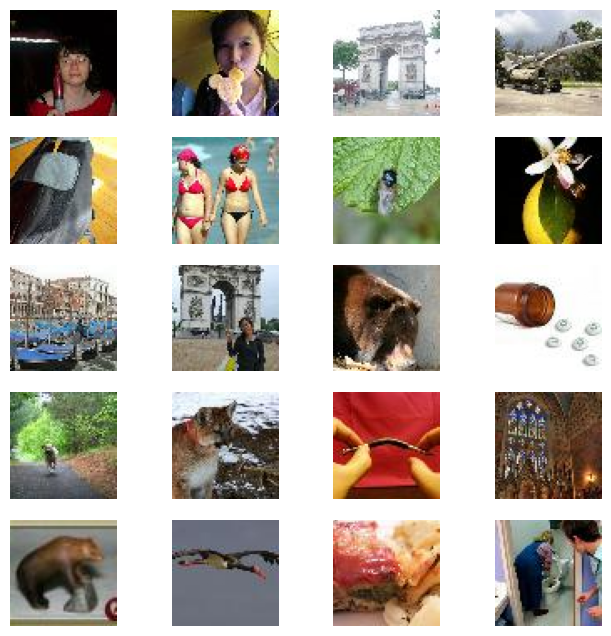

In [ ]:
# Show sample images from the training dataset
fig=plt.figure(figsize=(8, 8))
columns = 4
rows = 5
for i in range(1, columns*rows +1):
    # Randomly sample from training dataset
    img_idx = np.random.choice(X_train.shape[0])
    fig.add_subplot(rows, columns, i)
    plt.axis("off")
    plt.imshow(X_train[img_idx])
plt.show()

In [ ]:
# We split training set into two halfs.
# First half is used for training as secret images, second half for cover images.
# S: secret image
input_S = X_train[0:X_train.shape[0] // 2]
# C: cover image
input_C = X_train[X_train.shape[0] // 2:]

In [ ]:
beta = 1.0

# Loss for reveal network
def rev_loss(s_true, s_pred):
    # Loss for reveal network is: beta * |S-S'|
    return beta * K.sum(K.square(s_true - s_pred))

# Loss for the full model, used for preparation and hidding networks
def full_loss(y_true, y_pred):
    # Loss for the full model is: |C-C'| + beta * |S-S'|
    s_true, c_true = y_true[...,0:3], y_true[...,3:6]
    s_pred, c_pred = y_pred[...,0:3], y_pred[...,3:6]

    s_loss = rev_loss(s_true, s_pred)
    c_loss = K.sum(K.square(c_true - c_pred))
    return s_loss + c_loss

In [ ]:
# Returns the encoder as a Keras model, composed by Preparation and Hiding Networks.

def make_encoder(input_size):
    input_S = Input(shape=(input_size))
    input_C= Input(shape=(input_size))

    # Preparation Network
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_3x3')(input_S)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_4x4')(input_S)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_prep0_5x5')(input_S)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_prep1_5x5')(x)
    x = concatenate([x3, x4, x5])

    x = concatenate([input_C, x])

    # Hiding network
    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid0_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid1_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid2_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid3_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_hid4_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_hid4_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_hid5_5x5')(x)
    x = concatenate([x3, x4, x5])

    output_Cprime = Conv2D(3, (3, 3), strides = (1, 1), padding='same', activation='relu', name='output_C')(x)

    return Model(inputs=[input_S, input_C],
                 outputs=output_Cprime,
                 name = 'Encoder')

In [ ]:
# Returns the decoder as a Keras model, composed by the Reveal Network
def make_decoder(input_size, fixed=False):

    # Reveal network
    reveal_input = Input(shape=(input_size))


    input_with_noise = GaussianNoise(0.01, name='output_C_noise')(reveal_input)

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_3x3')(input_with_noise)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_4x4')(input_with_noise)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev0_5x5')(input_with_noise)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev1_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev2_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev3_5x5')(x)
    x = concatenate([x3, x4, x5])

    x3 = Conv2D(50, (3, 3), strides = (1, 1), padding='same', activation='relu', name='conv_rev4_3x3')(x)
    x4 = Conv2D(10, (4, 4), strides = (1, 1), padding='same', activation='relu', name='conv_rev4_4x4')(x)
    x5 = Conv2D(5, (5, 5), strides = (1, 1), padding='same', activation='relu', name='conv_rev5_5x5')(x)
    x = concatenate([x3, x4, x5])

    output_Sprime = Conv2D(3, (3, 3), strides = (1, 1), padding='same', activation='tanh', name='output_S')(x)

    if not fixed:
        return Model(inputs=reveal_input,
                     outputs=output_Sprime,
                     name = 'Decoder')
    else:
        return Network(inputs=reveal_input,
                         outputs=output_Sprime,
                         name = 'DecoderFixed')


In [ ]:
# Full model.
def make_model(input_size):
    input_S = Input(shape=(input_size))
    input_C= Input(shape=(input_size))

    encoder = make_encoder(input_size)

    decoder = make_decoder(input_size)
    decoder.compile(optimizer='adam', loss=rev_loss)
    decoder.trainable = False

    output_Cprime = encoder([input_S, input_C])
    output_Sprime = decoder(output_Cprime)

    autoencoder = Model(inputs=[input_S, input_C],
                        outputs=concatenate([output_Sprime, output_Cprime]))
    autoencoder.compile(optimizer='adam', loss=full_loss)

    return encoder, decoder, autoencoder

In [ ]:
def lr_schedule(epoch_idx):
    if epoch_idx < 200:
        return 0.001
    elif epoch_idx < 400:
        return 0.0003
    elif epoch_idx < 600:
        return 0.0001
    else:
        return 0.00003

In [ ]:

encoder_model, reveal_model, autoencoder_model = make_model(input_S.shape[1:])


autoencoder_model.load_weights('/content/drive/MyDrive/model_weights_best.hdf5')


In [ ]:
def train(e, lr=0.001):
    NB_EPOCHS = e
    BATCH_SIZE = 32

    encoder_model, reveal_model, autoencoder_model = make_model(input_S.shape[1:])

    # Set learning rate correctly
    K.set_value(autoencoder_model.optimizer.learning_rate, lr)
    K.set_value(reveal_model.optimizer.learning_rate, lr)

    m = input_S.shape[0]
    loss_history = []

    for epoch in range(NB_EPOCHS):
        np.random.shuffle(input_S)
        np.random.shuffle(input_C)
        t = tqdm(range(0, m, BATCH_SIZE), mininterval=0)

        ae_loss = []
        rev_loss_list = []

        for idx in t:
            batch_S = input_S[idx:min(idx + BATCH_SIZE, m)]
            batch_C = input_C[idx:min(idx + BATCH_SIZE, m)]

            C_prime = encoder_model.predict([batch_S, batch_C])
            aeLoss = autoencoder_model.train_on_batch(
                x=[batch_S, batch_C],
                y=np.concatenate((batch_S, batch_C), axis=3)
            )
            ae_loss.append(aeLoss)

            revLoss = reveal_model.train_on_batch(x=C_prime, y=batch_S)
            rev_loss_list.append(revLoss)

            t.set_description(
                f'Epoch {epoch + 1} | Batch: {idx} of {m}. Loss AE {np.mean(ae_loss):.2f} | Loss Rev {np.mean(rev_loss_list):.2f} | lr {lr}'
            )

        lr = lr_schedule(epoch + 1)
        mean_ae_loss = np.mean(ae_loss)
        loss_history.append(mean_ae_loss)

    autoencoder_model.save_weights('./model_weights.hdf5')
    autoencoder_model.save("model.h5")
    return loss_history, autoencoder_model


In [ ]:
loss_history, autoencoder_model = train(100)



In [ ]:
from keras.models import load_model

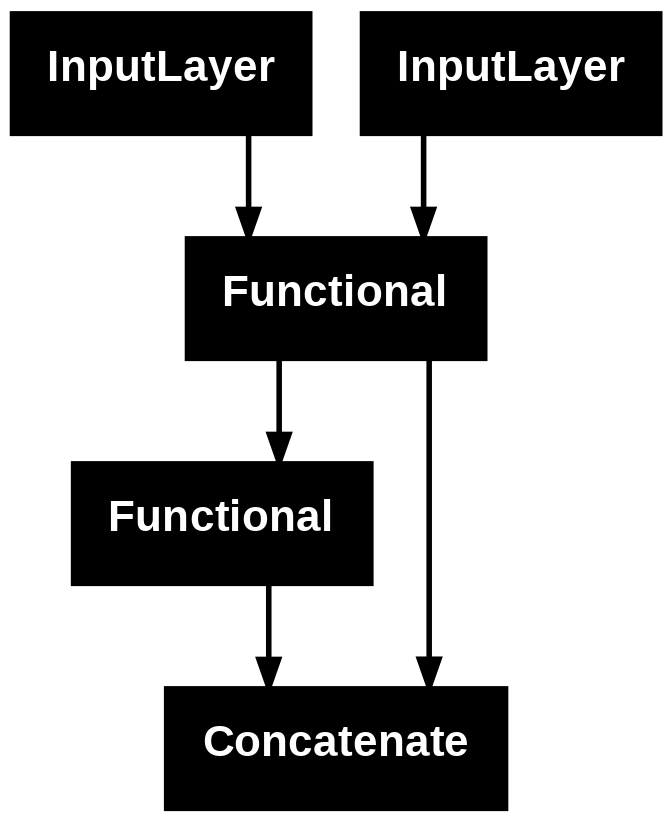

In [ ]:
import tensorflow as tf
tf.keras.utils.plot_model(autoencoder_model)

In [ ]:
# Retrieve decoded predictions.
decoded = autoencoder_model.predict([input_S, input_C])
decoded_S, decoded_C = decoded[...,0:3], decoded[...,3:6]

# Get absolute difference between the outputs and the expected values.
diff_S, diff_C = np.abs(decoded_S - input_S), np.abs(decoded_C - input_C)

32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step


In [ ]:
def pixel_errors(input_S, input_C, decoded_S, decoded_C):
    """Calculates mean of Sum of Squared Errors per pixel for cover and secret images. """
    see_Spixel = np.sqrt(np.mean(np.square(255*(input_S - decoded_S))))
    see_Cpixel = np.sqrt(np.mean(np.square(255*(input_C - decoded_C))))

    return see_Spixel, see_Cpixel

def pixel_histogram(diff_S, diff_C):
    """Calculates histograms of errors for cover and secret image. """
    diff_Sflat = diff_S.flatten()
    diff_Cflat = diff_C.flatten()

    fig = plt.figure(figsize=(15, 5))
    a=fig.add_subplot(1,2,1)

    imgplot = plt.hist(255* diff_Cflat, 100, normed=1, alpha=0.75, facecolor='red')
    a.set_title('Distribution of error in the Cover image.')
    plt.axis([0, 250, 0, 0.2])

    a=fig.add_subplot(1,2,2)
    imgplot = plt.hist(255* diff_Sflat, 100, normed=1, alpha=0.75, facSecolor='red')
    a.set_title('Distribution of errors in the Secret image.')
    plt.axis([0, 250, 0, 0.2])

    plt.show()

In [ ]:
# Print pixel-wise average errors in a 256 scale.
S_error, C_error = pixel_errors(input_S, input_C, decoded_S, decoded_C)

print ("S error per pixel [0, 255]:", S_error)
print ("C error per pixel [0, 255]:", C_error)

S error per pixel [0, 255]: 15.6182375
C error per pixel [0, 255]: 17.735594


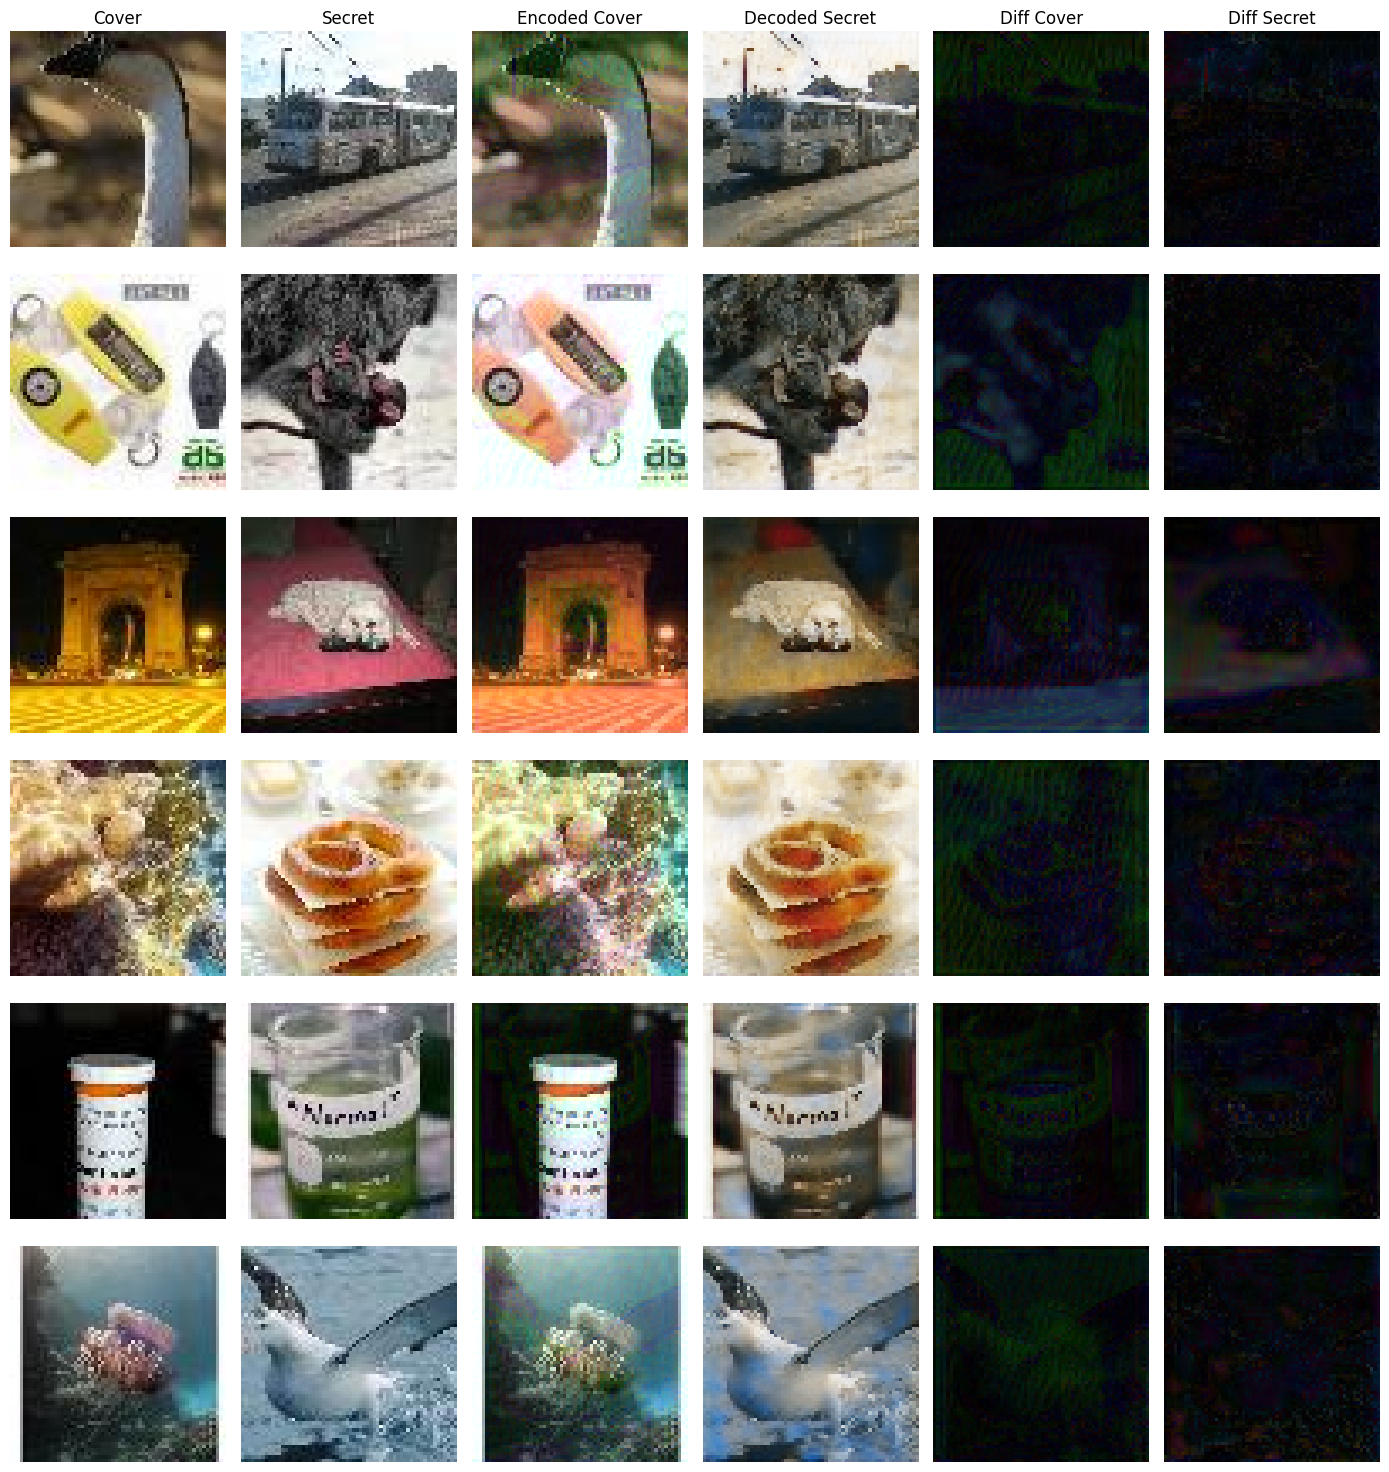

In [ ]:

n = 6
SHOW_GRAY = False
SHOW_DIFF = True
ENHANCE = 1


def rgb2gray(rgb):
    return np.dot(rgb[...,:3], [0.299, 0.587, 0.114])

def show_image(img, n_rows, n_col, idx, gray=False, first_row=False, title=None):
    ax = plt.subplot(n_rows, n_col, idx)
    if gray:
        plt.imshow(rgb2gray(img), cmap='gray')
    else:
        plt.imshow(img)
    ax.axis('off')
    if first_row:
        plt.title(title)

# ---- Visualization ----
plt.figure(figsize=(14, 15))

rand_indx = [random.randint(0, input_S.shape[0] - 1) for _ in range(n)]

for i, idx in enumerate(rand_indx):
    n_col = 6 if SHOW_DIFF else 4

    show_image(input_C[idx], n, n_col, i*n_col + 1, gray=SHOW_GRAY, first_row=(i==0), title='Cover')
    show_image(input_S[idx], n, n_col, i*n_col + 2, gray=SHOW_GRAY, first_row=(i==0), title='Secret')
    show_image(decoded_C[idx], n, n_col, i*n_col + 3, gray=SHOW_GRAY, first_row=(i==0), title='Encoded Cover')
    show_image(decoded_S[idx], n, n_col, i*n_col + 4, gray=SHOW_GRAY, first_row=(i==0), title='Decoded Secret')

    if SHOW_DIFF:
        show_image(diff_C[idx]*ENHANCE, n, n_col, i*n_col + 5, gray=SHOW_GRAY, first_row=(i==0), title='Diff Cover')
        show_image(diff_S[idx]*ENHANCE, n, n_col, i*n_col + 6, gray=SHOW_GRAY, first_row=(i==0), title='Diff Secret')

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import files
#files.download('./model_weights_best.hdf5')
#files.download('./model.h5')

In [ ]:
!pip install gradio

In [ ]:
import gradio as gr
import numpy as np
from PIL import Image

def process_images(cover_img, secret_img):
    # Convert to numpy + normalize
    cover = np.array(cover_img) / 255.0
    secret = np.array(secret_img) / 255.0


    cover = np.resize(cover, (64, 64, 3))
    secret = np.resize(secret, (64, 64, 3))
    secret = np.expand_dims(secret, axis=0)

    # Predict
    output = autoencoder_model.predict([secret, cover])

    decoded_secret = output[..., 0:3][0]
    encoded_cover = output[..., 3:6][0]

    # Convert back to image format
    encoded_cover = (encoded_cover * 255).astype(np.uint8)
    decoded_secret = (decoded_secret * 255).astype(np.uint8)

    return encoded_cover, decoded_secret


interface = gr.Interface(
    fn=process_images,
    inputs=[
        gr.Image(label="Upload Cover Image"),
        gr.Image(label="Upload Secret Image")
    ],
    outputs=[
        gr.Image(label="Encoded Cover Image"),
        gr.Image(label="Decoded Secret Image")
    ],
    title="🔐 Image Steganography using Deep Learning",
    description="Upload a cover image and a secret image to hide and reveal the secret."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://fd00cd4e3b8dc7f195.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from google.colab import files
import os

# Test images folder
img_folder = "/content/dataset/tiny-imagenet-200/test/images"

# Get first 10 images
images = os.listdir(img_folder)[:50]

for img in images:
    img_path = os.path.join(img_folder, img)
    print("Downloading:", img)
    files.download(img_path)

Downloading: test_429.JPEG


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: test_2448.JPEG


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloading: test_7.JPEG


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>